# Imports

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate
from hapi import *
from pylab import plot
import pickle
from scipy.stats import chi2
from scipy.stats import norm
import matplotlib.ticker as ticker
from pathlib import Path
import gc
from concurrent.futures import ProcessPoolExecutor, as_completed



# from bin_spec import bin_spectrum
import seaborn as sns

os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/')
from bin_spec import bin_spectrum

%matplotlib widget

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

# Configuration

In [5]:
DATA_DIR = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data"
hapi_data_dir = "HAPI_DB"
atmospheric_profile_path = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data/external/atmosphere_profile.csv"

db_begin('/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB')
df_atmospheric_profile_table = pd.read_csv(atmospheric_profile_path)

Using /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB

CH4
                     Lines parsed: 2946
CH4_iso2
                     Lines parsed: 11300
H2O_iso3
                     Lines parsed: 763
N2_iso1
                     Lines parsed: 24
H2O_iso1
                     Lines parsed: 2120
CH4_iso1
                     Lines parsed: 21535
H2O_main
                     Lines parsed: 1123
CH4_iso3
                     Lines parsed: 962
N2O_iso1
                     Lines parsed: 16617
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 983


# User parameters

In [6]:
wl_min = 7.0
wl_max = 8.5
native_dwn = 0.00005     # cm^-1, native HITRAN-resolution sampling (HAPI side)

wn_min = 1e4/wl_max
wn_max = 1e4/wl_min


# Helper Functions

### Modular

In [1]:
def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def compute_absorption_coefficient(molecule, isotope, dwn, altitude):
    """Compute absorption coefficient (cm^-1) for pure gas at layer conditions."""
    print(f"Computing coef for {molecule} iso{isotope} at alt {altitude}")
    M, __ = get_molecule_id(molecule)
    
    table_name = f"{molecule}_iso{isotope}"
    
    p_atm = df_atmospheric_profile_table["PRES_mb"].iloc[altitude] / 1013.25
    vmr = df_atmospheric_profile_table[f"{molecule}_ppmv"].iloc[altitude] / 1e6

    wn_grid, coef = absorptionCoefficient_Voigt(
        Components=[(M, isotope, vmr)],  # pure gas -> scale by vmr later
        Diluent={'self': vmr, 'air': 1.0 - vmr},
        SourceTables=table_name,
        WavenumberRange=(wn_min, wn_max),
        WavenumberStep=dwn,
        Environment={
            'T': df_atmospheric_profile_table["TEMP_K"].iloc[altitude], 
            'p': p_atm # Convert from mb to atmospheres
        },
        HITRAN_units=False  # Get absorption coefficient in cm^-1
    )

    
    return wn_grid, coef


def _compute_one(args):
    """Worker function – must be at module level for multiprocessing."""
    molecule, isotope, dwn, altitude = args
    wn, coef = compute_absorption_coefficient(molecule, isotope, dwn, altitude)
    return (molecule, isotope, altitude), (wn.astype(np.float32), coef.astype(np.float32))

def inject_poisson_noise(trans, snr, seed=42, mode='gaussian_approx'):

    """
    Inject noise into a transmission or reflectivity spectrum.
    
    Parameters:
        signal: array of transmission or reflectivity (0 to 1)
        snr: desired signal-to-noise ratio (scalar or per-bin array)
        mode: 'gaussian_approx' (recommended) or 'true_poisson'
    """
    np.random.seed(seed)
    
    signal = 1 - trans

    if mode == 'gaussian_approx':
        # Most common approach for spectra
        noise_std = signal / snr          # relative noise
        noise = np.random.normal(0, noise_std)
        noisy = trans + noise
        errorbars = noise_std
        
    elif mode == 'true_poisson':
        # True Poisson if you have absolute photon counts
        # Assume max_signal corresponds to e.g. 1e6 photons
        max_counts = 1e9                   # SGL high photon count!!
        counts = signal * max_counts
        noisy_counts = np.random.poisson(counts)
        noisy = noisy_counts / max_counts 
        errorbars = np.sqrt(counts) / max_counts   # sqrt(N) / N0
    
    else:
        raise ValueError("mode must be 'gaussian_approx' or 'true_poisson'")
    
    # Clip to physical range
    noisy = np.clip(noisy, 0.0, 1.0)
    
    return noisy, errorbars

def cross_correlate_spectra(template_spectra, test_spectra, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation between two spectra.
    Returns a dictionary with all relevant results.
    """
    # Zero-mean normalization
    template_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
    test_norm     = (test_spectra     - np.mean(test_spectra))     / np.std(test_spectra)
    
    # Cross-correlation
    ccf = correlate(template_norm, test_norm, mode='full')
    ccf /= np.sqrt(np.sum(template_norm**2) * np.sum(test_norm**2))
    
    # Lags
    if lags is None:
        lags = np.arange(-len(template_norm) + 1, len(template_norm))
    
    # Basic statistics
    max_corr = np.max(ccf)
    peak_idx = np.argmax(ccf)
    
    # Noise estimation from wings (excluding central peak)
    window_size = int(0.15 * len(ccf))
    noise_mask = np.ones(len(ccf), dtype=bool)
    noise_mask[max(0, peak_idx - window_size): min(len(ccf), peak_idx + window_size)] = False
    noise_values = ccf[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
    
    # SNR array
    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)
    
    results = {
        'ccf': ccf,
        'lags': lags,
        'max_correlation': max_corr,
        'peak_lag': lags[peak_idx],
        'noise_std': noise_std,
        'template_norm': template_norm,
        'test_norm': test_norm,
    }
    
    if return_full:
        results['ccf_clean'] = np.clip(np.nan_to_num(ccf, nan=0.0), 0, None)
    
    return results

def compute_log_likelihood(template, test, noise_std=None):
    """
    Log-likelihood computation according to ana's paper
    """
    # Zero mean subtraction (used in paper)
    f = template - np.mean(template)
    g = test - np.mean(test)

    N = len(f)

    
    # amplitude scaling a (force to one)
    a = 1 #np.dot(f, g) / np.dot(g, g) if np.dot(g, g) > 0 else 1.0

    # Variances and cross-covariance
    s_f2 = 1/N * np.sum(f**2)
    s_g2 = 1/N * np.sum(g**2) #np.mean((a * g)**2)
    R = 1/N * np.sum(f * g) #np.mean(f * a * g)
    
    # residuals = f - a * g
    
    # noise_std = np.std(residuals)
    

    # Log-likelihood from equation (9)
    argument = s_f2 - 2 * R + s_g2
    if argument <= 0:
        argument = 1e-10  # prevent log of negative/zero
        print('argument less than = 0')
    
    logL = - (N / 2.0) * np.log(argument)
    
    return logL, a

    # logL = -N * np.log(noise_std) - 0.5 * np.sum((residuals / noise_std)**2)

def load_scenario(scenario_key, out_dir="data/spectra_cache"):
    with open(f"{out_dir}/{scenario_key}.pkl", 'rb') as f:
        return pickle.load(f)

def load_abs_coef(molecule, isotope, altitude, 
                  cache_dir="/Volumes/externalssd/data/abs_coef_cache_dwn1e-6"):
    path = Path(cache_dir) / f"{molecule}_iso{isotope}_alt{altitude:03d}.npz"
    data = np.load(path)
    print(f'Loaded {molecule} isotope {isotope} at altitude {altitude}.')
    return data['wn'], data['coef']
    
    

### main

In [2]:
kB = 1.380649e-23  # Boltzmann constant, J/K


def precompute_abs_coefs_incremental(
    molecules_isotopes,
    dwn,
    altitudes,
    cache_dir="data/abs_coef_cache_dwn5e-5",
):
    """
    Compute absorption coefficients one-by-one ,
    save each result to its own file, then free RAM.
    Resumable: already-computed files are skipped.
    """
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    tasks = []
    for mol, iso in molecules_isotopes:
        for alt in altitudes:
            out_file = cache_dir / f"{mol}_iso{iso}_alt{alt:03d}.npz"
            if out_file.exists():
                print(f"Skipping {out_file.name}")
                continue
            tasks.append((mol, iso, alt))
    print(f"Tasks remaining: {len(tasks)}")

    for i, (mol, iso, alt) in enumerate(tasks, 1):
        print(f"[{i}/{len(tasks)}] Computing {mol} iso{iso} alt {alt} ...")
        
        wn, coef = compute_absorption_coefficient(mol, iso, dwn, alt)
        
        filename = f"{mol}_iso{iso}_alt{alt:03d}.npz"
        out_file = cache_dir / filename
        
        np.savez_compressed(
            out_file,
            wn=wn.astype(np.float32),
            coef=coef.astype(np.float32)
        )
        
        print(f"  → Saved {out_file.name}")
        
        del wn, coef
        gc.collect()

    print("All done.")

def compute_reflectivity(molecules_isotopes, dwn, cloud_top = 8.0, albedo = 0.3): #cloud_top is in km
    '''
    Input: tuple list?: [(molecule, isotopes), ...], dwn, cloud_top (km), albedo

    computes intensity across wavelength for earth-like atmosphere

    Output: wavelengths_µm (array), transmission (array), wn_grid_ref (array)
    '''

    alt_df = df_atmospheric_profile_table.copy().reset_index(drop=True)
    
    # Layers above the cloud deck
    above_cloud_mask = alt_df["ALT_km"] >= cloud_top
    above_df = alt_df[above_cloud_mask].reset_index(drop=True)
    
    print(f"Computing reflectivity above cloud top at {cloud_top} km ({len(above_df)} layers)")
    
    alt_km = above_df["ALT_km"].values
    dz_km = np.diff(alt_km, append=alt_km[-1] + np.median(np.diff(alt_km)))
    dz_cm = dz_km * 1e5
    
    #temporary debug:
    # dz_cm *= 0.1
    total_tau = None
    wn_grid_ref = None

    
    
    for mol, iso in molecules_isotopes:
        col_name = f"{mol}_ppmv"   # <--- exact match to CSV
        print(f"Looking for column: {col_name}")
        if col_name not in alt_df.columns:
            print("ERROR: Column not found! Using available VMR-like columns:", [c for c in alt_df.columns if 'ppm' in c.lower() or 'vmr' in c.lower()])
            continue
            
        print(f"→ Processing {mol} iso{iso}")
        
        for orig_idx, row in above_df.iterrows():   # orig_idx is the original altitude index
            # Load pre-computed coefficient for this original altitude
            wn_grid, coef = load_abs_coef(mol, iso, orig_idx+8)
            
            if wn_grid_ref is None:
                wn_grid_ref = wn_grid
            
            # ----- IMPORTANT -----
            # If the cached coefficient was already computed WITH the layer VMR,
            # do NOT multiply by vmr again.  Only multiply by dz.
            # If the cache was computed as pure-gas (vmr=1), then uncomment the next two lines:
            # ppmv = float(row[col_name])
            # vmr = ppmv * 1e-6
            # delta_tau = coef * vmr * dz_cm[above_df.index.get_loc(orig_idx)]
            
            # Assuming cache already contains the correct VMR:
            layer_pos = above_df.index.get_loc(orig_idx)   # position inside above_df
            delta_tau = coef * dz_cm[layer_pos]
            
            if total_tau is None:
                total_tau = np.zeros_like(coef, dtype=np.float32)
            total_tau += delta_tau
    
    if total_tau is None:
        raise ValueError("No tau accumulated")
    
    total_tau_roundtrip = 2*total_tau
    
    print(f"\nFINAL: max_tau_roundtrip = {np.max(total_tau_roundtrip):.2f}, mean_tau = {np.mean(total_tau_roundtrip):.2f}")
    transmission_roundtrip = np.exp(-total_tau_roundtrip)
    print(f"Transmission range: {transmission_roundtrip.min():.6f} to {transmission_roundtrip.max():.6f}")

    reflectivity = albedo * transmission_roundtrip
    
    wavelengths_um = (1e4 / wn_grid_ref)

    # Use float32 everywhere (halves memory vs float64)
    wavelengths_um = wavelengths_um.astype(np.float32)
    reflectivity = reflectivity.astype(np.float32)

    return wavelengths_um, reflectivity

def generate_res_dict(molecule_scenarios, resolutions, snrs=None, cloud_top=8.0, albedo=0.3, out_dir = 'data/spectra_cache'):
    """
    molecule_scenarios: list of lists like [[('H2O', 1)], [('CO2', 1)], [('CH4',1), ('N2O',1)]]
    resolutions: list of R values (e.g. [100, 500, 1000])
    snrs: list of SNRs to inject noise for (e.g. [50, 100, 200]). If None, only clean spectra.
    """

    Path(out_dir).mkdir(parents=True, exist_ok=True)

    if snrs is None:
        snrs = []
    
    res_dict = {}
    
    for scenario in molecule_scenarios:
        # Create a nice scenario key (e.g. 'H2O', 'CH4+N2O')
        if len(scenario) == 1:
            scenario_key = scenario[0][0]
        else:
            scenario_key = '+'.join([mol for mol, iso in scenario])

        scenario_dict = {} #initializing scenario_dictionary to be cached
        
        print(f"Computing high-res for scenario: {scenario_key}")
        
        # Compute once at very high resolution
        wl_high, refl_high = compute_reflectivity(
            scenario, 
            dwn=native_dwn, 
            cloud_top=cloud_top, 
            albedo=albedo
        )
        
        print(f"  High-res grid size: {len(wl_high)} points")
        
        for R in resolutions:

            res_key = int(R)
            
            if res_key not in res_dict:
                res_dict[res_key] = {}

            # Bin the clean spectrum
            wl_binned, refl_binned, _ = bin_spectrum(wl_high, refl_high, R)

            # write to entry to be stored in scenario_dict later
            entry = {
                'wavelength_grid': wl_binned.astype(np.float32),
                'reflectivity_clean': refl_binned.astype(np.float32),
                'resolution': res_key
            }
            
            
            # Add noisy versions for each SNR
            for snr in snrs:
                noisy, errors = inject_poisson_noise(refl_binned, snr=snr)
                entry[f'reflectivity_snr{snr}'] = noisy
                entry[f'error_snr{snr}'] = errors
            
            scenario_dict[R] = entry

        # write this scenario to local path
        out_path = Path(out_dir) / f"{scenario_key}.pkl"
        with open(out_path, 'wb') as f:
            pickle.dump(scenario_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
        
        print(f"  Cached scenario {scenario} → {out_path}")
        
        # Explicitly free memory
        del wl_high, refl_high, scenario_dict
        gc.collect()
        
        # res_dict[res_key][scenario_key] = entry
    
    return res_dict


def cross_correlate_two_templates(template_A, template_B, test_scenario, out_dir = "data/spectra_cache"):
    """
    Cross-correlate two specific clean templates against the noisy versions
    of a single test scenario.
    """

    print(f"Loading scenarios...")
    data_A = load_scenario(template_A, out_dir)
    data_B = load_scenario(template_B, out_dir)
    data_test = load_scenario(test_scenario, out_dir)

    # Only use resolutions that exist in all three
    common_resolutions = sorted(
        set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
    )

    records = []

    for r in common_resolutions:
        # Check that everything we need exists
        template_A_spec = data_A[r]['reflectivity_clean']
        template_B_spec = data_B[r]['reflectivity_clean']

        # Loop over noisy versions of the test scenario at this resolution
        for key in data_test[r]:
            if not key.startswith('reflectivity_snr'):
                continue

            noisy_spec = data_test[r][key]
            snr_value = int(key.split('snr')[-1])

            if len(template_A_spec) != len(noisy_spec):
                continue

            # Log-likelihoods
            log_lik_A, _ = compute_log_likelihood(template_A_spec, noisy_spec)
            log_lik_B, _ = compute_log_likelihood(template_B_spec, noisy_spec)

            delta_ll = log_lik_B - log_lik_A
            ts = 2 * delta_ll
            p = chi2.sf(ts, df=1)
            sigma = norm.isf(p / 2.0)

            records.append({
                'resolution': r,
                'snr': snr_value,
                'delta_logL': delta_ll,
                'sigma': sigma,
            })

    # Free memory
    del data_A, data_B, data_test
    import gc
    gc.collect()

    df = pd.DataFrame(records)
    print(f"Generated {len(df)} records for {template_A} vs {template_B}")
    return df
    
def cross_correlate_spectra_in_dict(parent_dict, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation for all scenarios in input spectral dictionary
    
    Returns a dictionary with all relevant results.
    """

    records = []

    for r, res_data in parent_dict.items():
        for scen_template in res_data:
            clean_key = 'reflectivity_clean'
            if clean_key not in res_data[scen_template]:
                continue

            template_spectra = res_data[scen_template][clean_key]

            for scen_test in res_data:
                for key in list(res_data[scen_test].keys()):
                    if not key.startswith('reflectivity_snr'):
                        continue

                    noisy_spectra = res_data[scen_test][key]
                    snr_value = key.split('snr')[-1]

                    if len(template_spectra) != len(noisy_spectra):
                        continue

                    results = cross_correlate_spectra(template_spectra, noisy_spectra)

                    # Compute the log likelihood
                    log_lik, _ = compute_log_likelihood(template_spectra, noisy_spectra, results['noise_std'])

                    records.append({
                        'resolution': r,
                        'template_scenario': scen_template,
                        'test_scenario': scen_test,
                        'snr': int(snr_value),
                        'max_correlation': results['max_correlation'],
                        'peak_lag': results['peak_lag'],
                        'noise_std': results['noise_std'],
                        # 'ccf': results['ccf'],
                        # 'lags': results['lags'],
                        'log_lik': log_lik
                    })
    df = pd.DataFrame(records)
    print(f"Generated {len(df)} cross-correlation records")
    return df



# Dictionary generation

In [7]:
#define the molecules to compute
molecules_isotopes = [
    ('H2O', 1),
    ('CH4', 1),
    ('N2O', 1),
]

# Selecting only layers above the cloud top
cloud_top_km = 8.0
altitudes = df_atmospheric_profile_table.index[
    df_atmospheric_profile_table["ALT_km"] >= cloud_top_km
].tolist()

print(f"Will compute {len(molecules_isotopes)} molecules × {len(altitudes)} layers")


#precompute the absorption coefficientss
precompute_abs_coefs_incremental(
    molecules_isotopes = molecules_isotopes,
    dwn                = 0.000001,          
    altitudes          = altitudes,
    cache_dir          = "/Volumes/externalssd/data/abs_coef_cache_dwn1e-6",
)

Will compute 3 molecules × 42 layers


PermissionError: [Errno 13] Permission denied: '/Volumes/externalssd'

In [ ]:
scenarios = [[('H2O', 1), ('CH4', 1), ('N2O', 1)], [('H2O', 1), ('CH4', 1)]]#, [('CH4', 1), ('N2O', 1)]] #[('H2O', 1)], [('N2O', 1)], [('CH4', 1)], [('H2O', 1), ('N2O', 1)]

# recreating tables with correct wvenumber range
# mols = [('H2O', 1), ('CH4', 1), ('N2O', 1)]
# for mol, isotope in mols:
#     M, _ = get_molecule_id(mol)
#     table_name = f'{mol}_iso{isotope}'
#     fetch(table_name,M,isotope,wn_min,wn_max)

resolutions = [1e2, 1e3, 1e4, 1e5, 1e6]#, 1e8, 1.29e8]
snrs = [3, 5, 10, 15, 20, 25, 50]#, 100, 200, 300]#, 1000]

res_dict = generate_res_dict(scenarios, resolutions, snrs, cloud_top=8.0, albedo=0.3)

Computing high-res for scenario: H2O+CH4+N2O
Computing reflectivity above cloud top at 8.0 km (42 layers)
Looking for column: H2O_ppmv
→ Processing H2O iso1
Loaded H2O isotope 1 at altitude 8.
Loaded H2O isotope 1 at altitude 9.
Loaded H2O isotope 1 at altitude 10.


In [ ]:
# plt.close('all')
# plt.figure(figsize=(10,6))

# resolution_to_plot = 1e7
# scenario_to_plot = 'H2O+CH4+N2O'
# snr_to_plot_a = 50
# snr_to_plot_b = 100
# clean_plot = False

# data = res_dict[resolution_to_plot][scenario_to_plot]
# data_temp = res_dict[resolution_to_plot]['H2O+CH4']
# # data_temp2 = res_dict[resolution_to_plot]['N2O']

# plt.plot(data['wavelength_grid'], data[f'reflectivity_snr{snr_to_plot_b}'], label = f'{scenario_to_plot} Reflectivity at R = {resolution_to_plot}, SNR = {snr_to_plot_b}', alpha = 0.6)
# plt.plot(data['wavelength_grid'], data['reflectivity_clean'], label = f'H2O+CH4+N2O Reflectivity at R = {resolution_to_plot}', alpha = 0.6)
# plt.plot(data_temp['wavelength_grid'], data_temp[f'reflectivity_clean'], label = f'H2O+CH4 Reflectivity at R = {resolution_to_plot}', alpha = 0.6)


# # plt.plot(data_temp['wavelength_grid'], data_temp2['reflectivity_clean'], label = f'N2O Reflectivity at R = {resolution_to_plot}')


# plt.title('Reflectivity Spectra')
# plt.grid()
# # plt.legend()
# plt.show()

# Cross Correlation Tests

In [ ]:
plt.close('all')
template_A = 'H2O+CH4'
template_B = 'H2O+CH4+N2O' 
test_scen = 'H2O+CH4+N2O'
df_cc = cross_correlate_two_templates(res_dict, template_A=template_A, template_B=template_B, test_scenario=test_scen)


# df_A = df_cc[(df_cc['template_scenario'] == template_A) & (df_cc['test_scenario'] == test_scen)].copy()
# df_B = df_cc[(df_cc['template_scenario'] == template_B) & (df_cc['test_scenario'] == test_scen)].copy()

# print("Rows A:", len(df_A), "Rows B:", len(df_B))

NameError: name 'plt' is not defined

# Plotting Results

### Log-likelihood metric

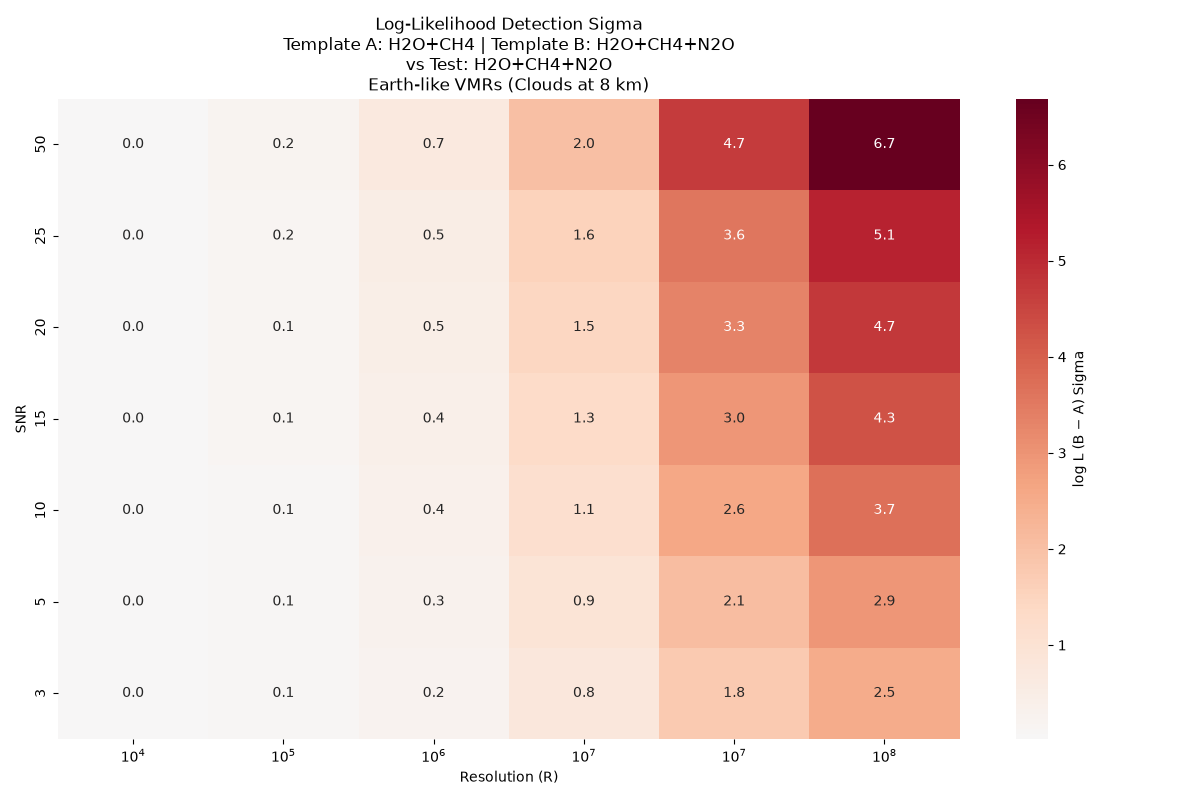

In [ ]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# Use log-likelihood difference (A - B)
# merged['delta_logL'] = merged['log_lik_B'] - merged['log_lik_A']

# Optional: compute significance (how many sigma the difference is)
# merged['delta_significance'] = merged['delta_logL'] / np.sqrt(merged['noise_std_A']**2 + merged['noise_std_B']**2)

# ======================
# Pivot for heatmap
# ======================
pivot = df_cc.pivot_table(
    index='snr', 
    columns='resolution', 
    values='sigma',        # or 'delta_significance'
    aggfunc='mean'
).sort_index(ascending=False)   # SNR increasing upwards

# ======================
# Annotation
# ======================
annot = pivot.copy().astype(str)

for i, snr in enumerate(pivot.index):
    for j, res in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        annot.iloc[i, j] = f"{val:.1f}"

# ======================
# Plot
# ======================
plt.figure(figsize=(12, 8))

ax=sns.heatmap(
    pivot,
    cmap='RdBu_r',           
    center=0,
    annot=annot,
    fmt='', 
    cbar_kws={'label': 'log L (B − A) Sigma'}
)



xticklabels = [f"$10^{{{int(np.log10(r))}}}$" if r >= 1000 else str(int(r)) 
               for r in pivot.columns]
ax.set_xticklabels(xticklabels)

plt.xlabel('Resolution (R)')
plt.ylabel('SNR')
plt.title(
    f'Log-Likelihood Detection Sigma\n'
    f'Template A: {template_A} | Template B: {template_B}\n'
    f'vs Test: {test_scen}\n'
    'Earth-like VMRs (Clouds at 8 km)'
)

plt.tight_layout()
plt.show()

### Detection Significance

In [ ]:
# merged = pd.merge(df_A, df_B, on=['resolution', 'snr'], suffixes=('_A', '_B'))

# merged['delta'] = merged['max_correlation_A'] - merged['max_correlation_B']
# merged['difference'] = merged['ccf_A'] - merged['ccf_B']   # array subtraction


# def compute_difference_stats(row):
#     diff = row['difference']
#     if not isinstance(diff, np.ndarray):
#         diff = np.array(diff)
    
#     peak_idx = (len(diff)-1)//2#np.argmax(np.abs(diff))
#     # print(len(diff))
#     # print(peak_idx)
#     peak_diff = diff[peak_idx]
    
#     length = len(diff)
#     window = int(0.15 * length)
#     noise_mask = np.ones(length, dtype=bool)
#     noise_mask[max(0, peak_idx - window): min(length, peak_idx + window)] = False
    
#     noise_values = diff[noise_mask]
#     noise_std = np.std(noise_values) if len(noise_values) > 10 else np.std(diff)

#     # noise_std = np.sqrt(row['noise_std_A']**2+row['noise_std_B']**2)
    
#     confidence = peak_diff / noise_std if noise_std > 0 else 0

#     # print(f'Standard deviation: {noise_std}, systemic difference: {peak_diff}')
    
#     return pd.Series({
#         'peak_difference': peak_diff,
#         'peak_lag': row['lags'][peak_idx] if 'lags' in row else peak_idx,
#         'noise_std': noise_std,
#         'difference_confidence': confidence
#     })

# stats = merged.apply(compute_difference_stats, axis=1)
# merged = pd.concat([merged, stats], axis=1)

In [ ]:
# plt.figure(figsize=(10,6))

# pivot = merged.pivot_table(index='snr', columns='resolution', values='difference_confidence').sort_index(ascending=False)

# sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdBu", center=0)
# plt.title(f"Correlation Significance\n (({template_A}) - ({template_B}) / std(diff)) vs Test spectra {test_scen}")

# plt.show()